In [53]:
import pandas as pd
import numpy as np
from skimage import exposure
from hdr_adjustments import hdr_adjustment
import matplotlib.pyplot as plt
import os
from skimage import io
from matplotlib.colors import ListedColormap, BoundaryNorm

In [54]:
AZIMUTH_NORM_SCALE = 360
ZENITH_NORM_SCALE = 135
# Since degree resolution=0.25: 360/0.25=1440
CANVAS_WIDTH = 1440 
CANVAS_HEIGHT = 540


## Initialize Input Paths

In [55]:
# filename = os.path.join('C:/Users/fzhcis/Documents/mylab/tls_demo/demo_files/UMBCBL009_2024-03-28-02-47-26_ALRSET12_060180_000200.800_1830507489.txt')
# filename = os.path.join('C:/Users/fzhcis/Documents/projects/from_RobC/for_Fei/data/palau_2024/AURSET2/UMBCBL009_2024-03-27-23-59-45_AURSET2North_060180_000116.799_1327754030.txt')
filename = os.path.join('C:/Users/fzhcis/Documents/projects/from_RobC/for_Fei/data/palau_2024/NGERURSET2/UMBCBL009_2024-03-25-21-51-30_NGERURSET2North_060180_000225.800_708743674.txt')
saveflag = True

seg_map_path = './cvat/tls-label-cvat-segmentation-mask-2/SegmentationClass/Mean Intensity Image.png'
save_pts_with_colors = False

output_dir = './outputs'

## Preprocess the Point Cloud data
- read the data as a pandas dataframe
- Clean it
  - Filter with first return and non-extreme intensity values
- prepare x_pix and y_pix columns for grouping

In [56]:
def preprocess_point_cloud(filename: str) -> pd.DataFrame:
    """
    Preprocess a point cloud data file and map scalar field values to pixel coordinates.
    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    Returns:
    pandas.DataFrame: A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    The input CSV file is expected to have the following columns:
    - 'X': X coordinate of the point.
    - 'Y': Y coordinate of the point.
    - 'Z': Z coordinate of the point.
    - 'zenith': Zenith angle of the point.
    - 'azimuth': Azimuth angle of the point.
    - 'range1metres': Range to the point in meters.
    - 'Intensity': Intensity value of the point.
    - 'Return Number': Return number of the point.
    The function performs the following steps:
    1. Reads the file into a pandas DataFrame.
    2. Filters the DataFrame to include only points with a return number of 1 and intensity between 50 and 1000.
    3. Maps the azimuth and zenith angles to pixel coordinates (x_pix, y_pix) within the bounds of a predefined canvas size.
    4. Ensures the pixel indices are within the bounds of the canvas.
    """
    
    # Step 1: Read the file as a pandas DataFrame
    df = pd.read_csv(
        str(filename),
        delimiter=',', 
        names=['X', 'Y', 'Z', 'zenith', 'azimuth', 'range1metres', 'Intensity', 'Return Number']
    )

    # Step 2: Clean the dataset
    df_filtered = df[
        (df['Return Number'] == 1) &
        (df['Intensity'] >= 50) &
        (df['Intensity'] <= 1000) & 
        (df['range1metres'] >= 0.25)
        
    ]

    # Step 3: Extract scanning angles and map to pixel coordinates
    # Map azimuth (0-360 degrees) to x-coordinate (0 to CANVAS_WIDTH-1)
    df_filtered['x_pix'] = ((df_filtered['azimuth'] / AZIMUTH_NORM_SCALE) * (CANVAS_WIDTH - 1)).astype(int)

    # Map zenith (0-135 degrees) to y-coordinate (0 to CANVAS_HEIGHT-1), flipping the y-axis
    df_filtered['y_pix'] = (((ZENITH_NORM_SCALE - df_filtered['zenith']) / ZENITH_NORM_SCALE) * (CANVAS_HEIGHT - 1)).astype(int)

    # Ensure pixel indices are within bounds
    df_filtered['x_pix'] = df_filtered['x_pix'].clip(0, CANVAS_WIDTH - 1)
    df_filtered['y_pix'] = df_filtered['y_pix'].clip(0, CANVAS_HEIGHT - 1)

    return df_filtered


## Prepare the functions for displaying images.

In [57]:
def display_unwrapped_images(subplot_images: tuple[np.ndarray], 
                             titles: tuple[str],
                             colormap: str = 'plasma', 
                             saveflag: bool = False) -> None:
    """
    Display two images with titles and colorbars.

    Parameters:
    subplot1_image (np.ndarray): The first image to display.
    subplot2_image (np.ndarray): The second image to display.
    title1 (str): Title for the first image.
    title2 (str): Title for the second image.
    colormap (str): Colormap to use for displaying the images. Default is 'plasma'.
    saveflag (bool): If True, save the images to the output_dir. Default is False.

    Returns:
    None
    """
    num_subplots = len(subplot_images)
    fig, axes = plt.subplots(num_subplots, 1, figsize=(12, 4*num_subplots))

    # Set the colormap to something more visually friendly
    colormap = colormap  # e.g.: 'jet', 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
    aspect_ratio = CANVAS_HEIGHT / CANVAS_WIDTH

    # Define custom ticks using np.linspace
    y_ticks = np.linspace(0, ZENITH_NORM_SCALE, CANVAS_HEIGHT + 1)
    x_ticks = np.linspace(0, AZIMUTH_NORM_SCALE, CANVAS_WIDTH + 1)

    for ax, subplot_img, title in zip(axes, subplot_images, titles):
        im = ax.imshow(subplot_img, cmap=colormap, aspect='auto', extent=[x_ticks[0], x_ticks[-1], y_ticks[0], y_ticks[-1]])
        ax.set_xlabel('Azimuth Angle (degrees)')
        ax.set_ylabel('Zenith from Z (degree)')
        ax.set_xticks(x_ticks[::int(len(x_ticks) / 10)])  # Reduce the number of x-ticks to avoid overlap
        ax.set_yticks(y_ticks[::int(len(y_ticks) / 10)])  # Reduce the number of y-ticks for readability
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust colorbar size
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

    if saveflag:
        for i, title in enumerate(titles):
            plt.imsave(f'{output_dir}/{title}.png', subplot_images[i], cmap=colormap)
        
        fig.savefig(f'{output_dir}/combined_image.png')
        print(f'Images saved to {output_dir} directory')


### Observe the density map and histograms

In [58]:
def display_density_images(image_data: np.ndarray, saveflag: bool = False) -> None:
    """
    Display a density map image with a discrete colormap and optionally save the image.
    Parameters:
    -----------
    image_data : np.ndarray
        A 2D array representing the density of points per pixel.
    saveflag : bool, optional
        If True, the function will save the displayed image and the raw image data to the output_dir directory (default is False).
    Returns:
    --------
    None
    Notes:
    ------
    - The colormap used is 'jet' with the color for zero density set to black.
    - The colorbar is labeled with integer ticks corresponding to the density values.
    - If `saveflag` is True, two images are saved:
        1. 'Point Density Map raw.png' - the raw image data with the 'jet' colormap.
        2. 'Point Density Map.png' - the displayed image with a resolution of 600 dpi.
    """
    # Display the image with the discrete colormap
    fig = plt.figure(figsize=(12, 4))
    max_density = int(image_data.max())

    colors = plt.get_cmap('jet', max_density+1)(np.arange(max_density+1))
    colors[0] = [0, 0, 0, 1]  # Set the color for zero to black (RGBA)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, max_density+1.5, 1), cmap.N)  # Discrete boundaries at each integer
    
    plt.imshow(image_data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(ticks=range(max_density+1))  # Add colorbar with integer ticks
    cbar.set_ticklabels([str(i) for i in range(max_density+1)])  # Set labels to match each value
    cbar.set_label('Points per pixel')
    plt.title('Point Density Map')
    plt.show()

    if saveflag:
        plt.imsave(f'{output_dir}/Point Density Map raw.png', image_data, cmap=cmap)
        fig.savefig(f'{output_dir}/Point Density Map.png', dpi=600)
        print(f'Images saved to {output_dir} directory')


In [59]:
def get_image_histogram(image_data: np.ndarray, title: str = '', saveflag: bool = False) -> None:
    """
    Generate and display a histogram of pixel values in the image data.

    Parameters:
    -----------
    image_data : np.ndarray
        A 2D array representing the density of points per pixel.
    title : str
        Title of the histogram plot.
    saveflag : bool, optional
        If True, the function will save the histogram plot to the output_dir directory (default is False).

    Returns:
    --------
    None
    """
    # Flatten the data to get a 1D array of values
    flattened_data = image_data.flatten()

    # Get unique values and their counts
    unique_values = np.unique(flattened_data)
    
    # Determine the number of bins
    if len(unique_values) > 20:
        bins = 20  # Limit bins to 20 if there are more than 20 unique values
        hist_values, bin_edges = np.histogram(flattened_data, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        normalized_counts = hist_values / hist_values.sum()  # Normalize counts
    else:
        values, counts = np.unique(flattened_data, return_counts=True)
        hist_values = counts
        bin_centers = values
        normalized_counts = hist_values / hist_values.sum()  # Normalize counts

    # Create the bar plot
    fig, ax1 = plt.subplots()

    # Absolute count bars
    ax1.bar(bin_centers, hist_values, width=0.8 * (bin_centers[1] - bin_centers[0]) if len(bin_centers) > 1 else 1,
            color='blue', alpha=0.7, label='Absolute Count')
    ax1.set_xlabel('Pixel Value')
    ax1.set_ylabel('Absolute Count', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Add a second y-axis for normalized portion
    ax2 = ax1.twinx()
    ax2.plot(bin_centers, normalized_counts, color='orange', marker='o', linestyle='-', label='Normalized Portion')
    ax2.set_ylabel('Normalized Portion', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Add grid, legend, and title
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.title(f'Histogram of Pixel Values ({title})')
    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

    fig.tight_layout()
    plt.show()
    print(f'Histogram:\nValues: {bin_centers}\nCounts: {hist_values}\nNormalized Counts: {normalized_counts.round(3)}')
    
    if saveflag:
        fig.savefig(f'{output_dir}/Pixel Value Histogram_{title}.png', dpi=300)
        print(f'Histogram saved to {output_dir} directory')


In [61]:
def unwrap_point_cloud_to_2d_images(filename: str, hdr_method: str = 'clahe') -> tuple[pd.DataFrame, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel value with different kinds of scalar fields.
    Including density, intensity, range, and range-xy images.

    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    hdr_method (str): The HDR adjustment hdr_method to apply. Default is 'clahe'.
    saveflag (bool): If True, save the images to the output_dir directory. Default is True.

    Returns:
    df_filtered (pd.DataFrame): A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: A tuple containing the density image, adjusted intensity image, adjusted range image, and adjusted range-xy image.
    """
    # Step 5: Fill in the canvas pixels with scalar field values
    ## Preprocess the point cloud data
    df_filtered = preprocess_point_cloud(filename)
    grouped = df_filtered.groupby(['y_pix', 'x_pix'])

    ## Compute intensity and range per pixel. 
    ## Since less than 0.1% of the pixels contain more than one point, it doesn't matter if we use mean or max.
    group_intensity = grouped['Intensity'].mean()
    group_range = grouped['range1metres'].max()
    pts_per_pixel = grouped.size()
    range_x = grouped['X'].mean()
    range_y = grouped['Y'].mean()
    range_xy = np.sqrt(range_x**2 + range_y**2)

    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    intensity_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_xy_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)  # range in xy plane
    density_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    pxpy_indices = np.array(group_intensity.index.tolist())
    intensity_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_intensity.values
    range_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_range.values
    density_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = pts_per_pixel.values
    range_xy_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = range_xy.values

    # Step 6: Apply HDR adjustment to intensity and range images
    intensity_image_adjusted = hdr_adjustment(intensity_image, method='clahe')
    range_image_adjusted = hdr_adjustment(range_image, method=hdr_method)
    range_xy_image_adjusted = hdr_adjustment(range_xy_image, method=hdr_method)

    output_images = (density_image, intensity_image_adjusted, range_image_adjusted, range_xy_image_adjusted, intensity_image, range_image, range_xy_image)
   
    return df_filtered, output_images


## Run the above process
- display density map and density histogram
- display Intensity Map, Range Map, and Range-XY Map

C:\Users\fzhcis\AppData\Local\Temp\ipykernel_13988\1341423265.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['x_pix'] = ((df_filtered['azimuth'] / AZIMUTH_NORM_SCALE) * (CANVAS_WIDTH - 1)).astype(int)
C:\Users\fzhcis\AppData\Local\Temp\ipykernel_13988\1341423265.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['y_pix'] = (((ZENITH_NORM_SCALE - df_filtered['zenith']) / ZENITH_NORM_SCALE) * (CANVAS_HEIGHT - 1)).astype(int)
C:\Users\fzhcis\AppData\Local\Temp\ipykernel_13988\13

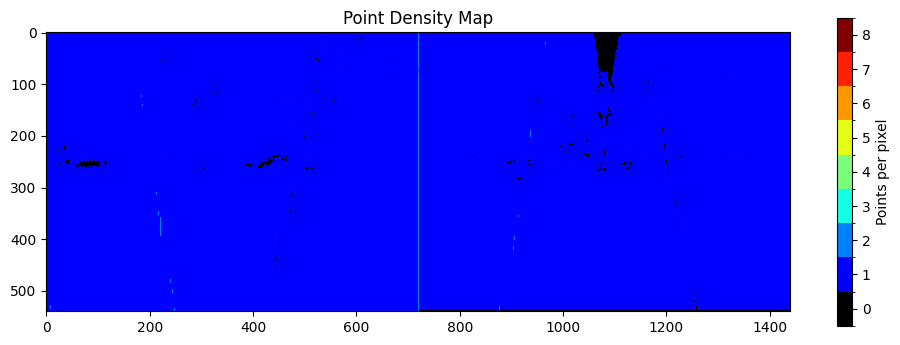

Images saved to ./outputs directory


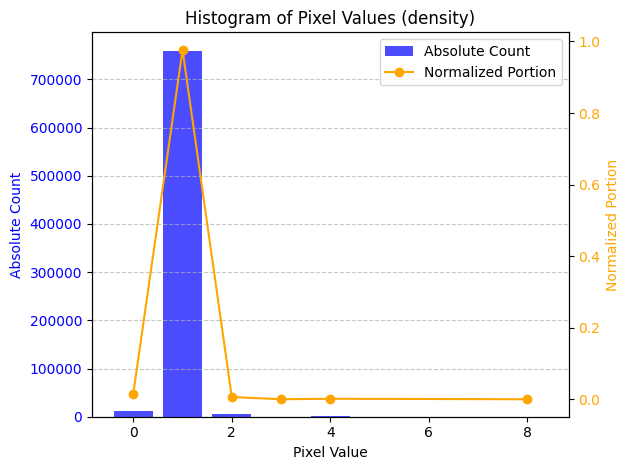

Histogram:
Values: [0. 1. 2. 3. 4. 8.]
Counts: [ 12184 759503   4827     19   1065      2]
Normalized Counts: [0.016 0.977 0.006 0.    0.001 0.   ]
Histogram saved to ./outputs directory


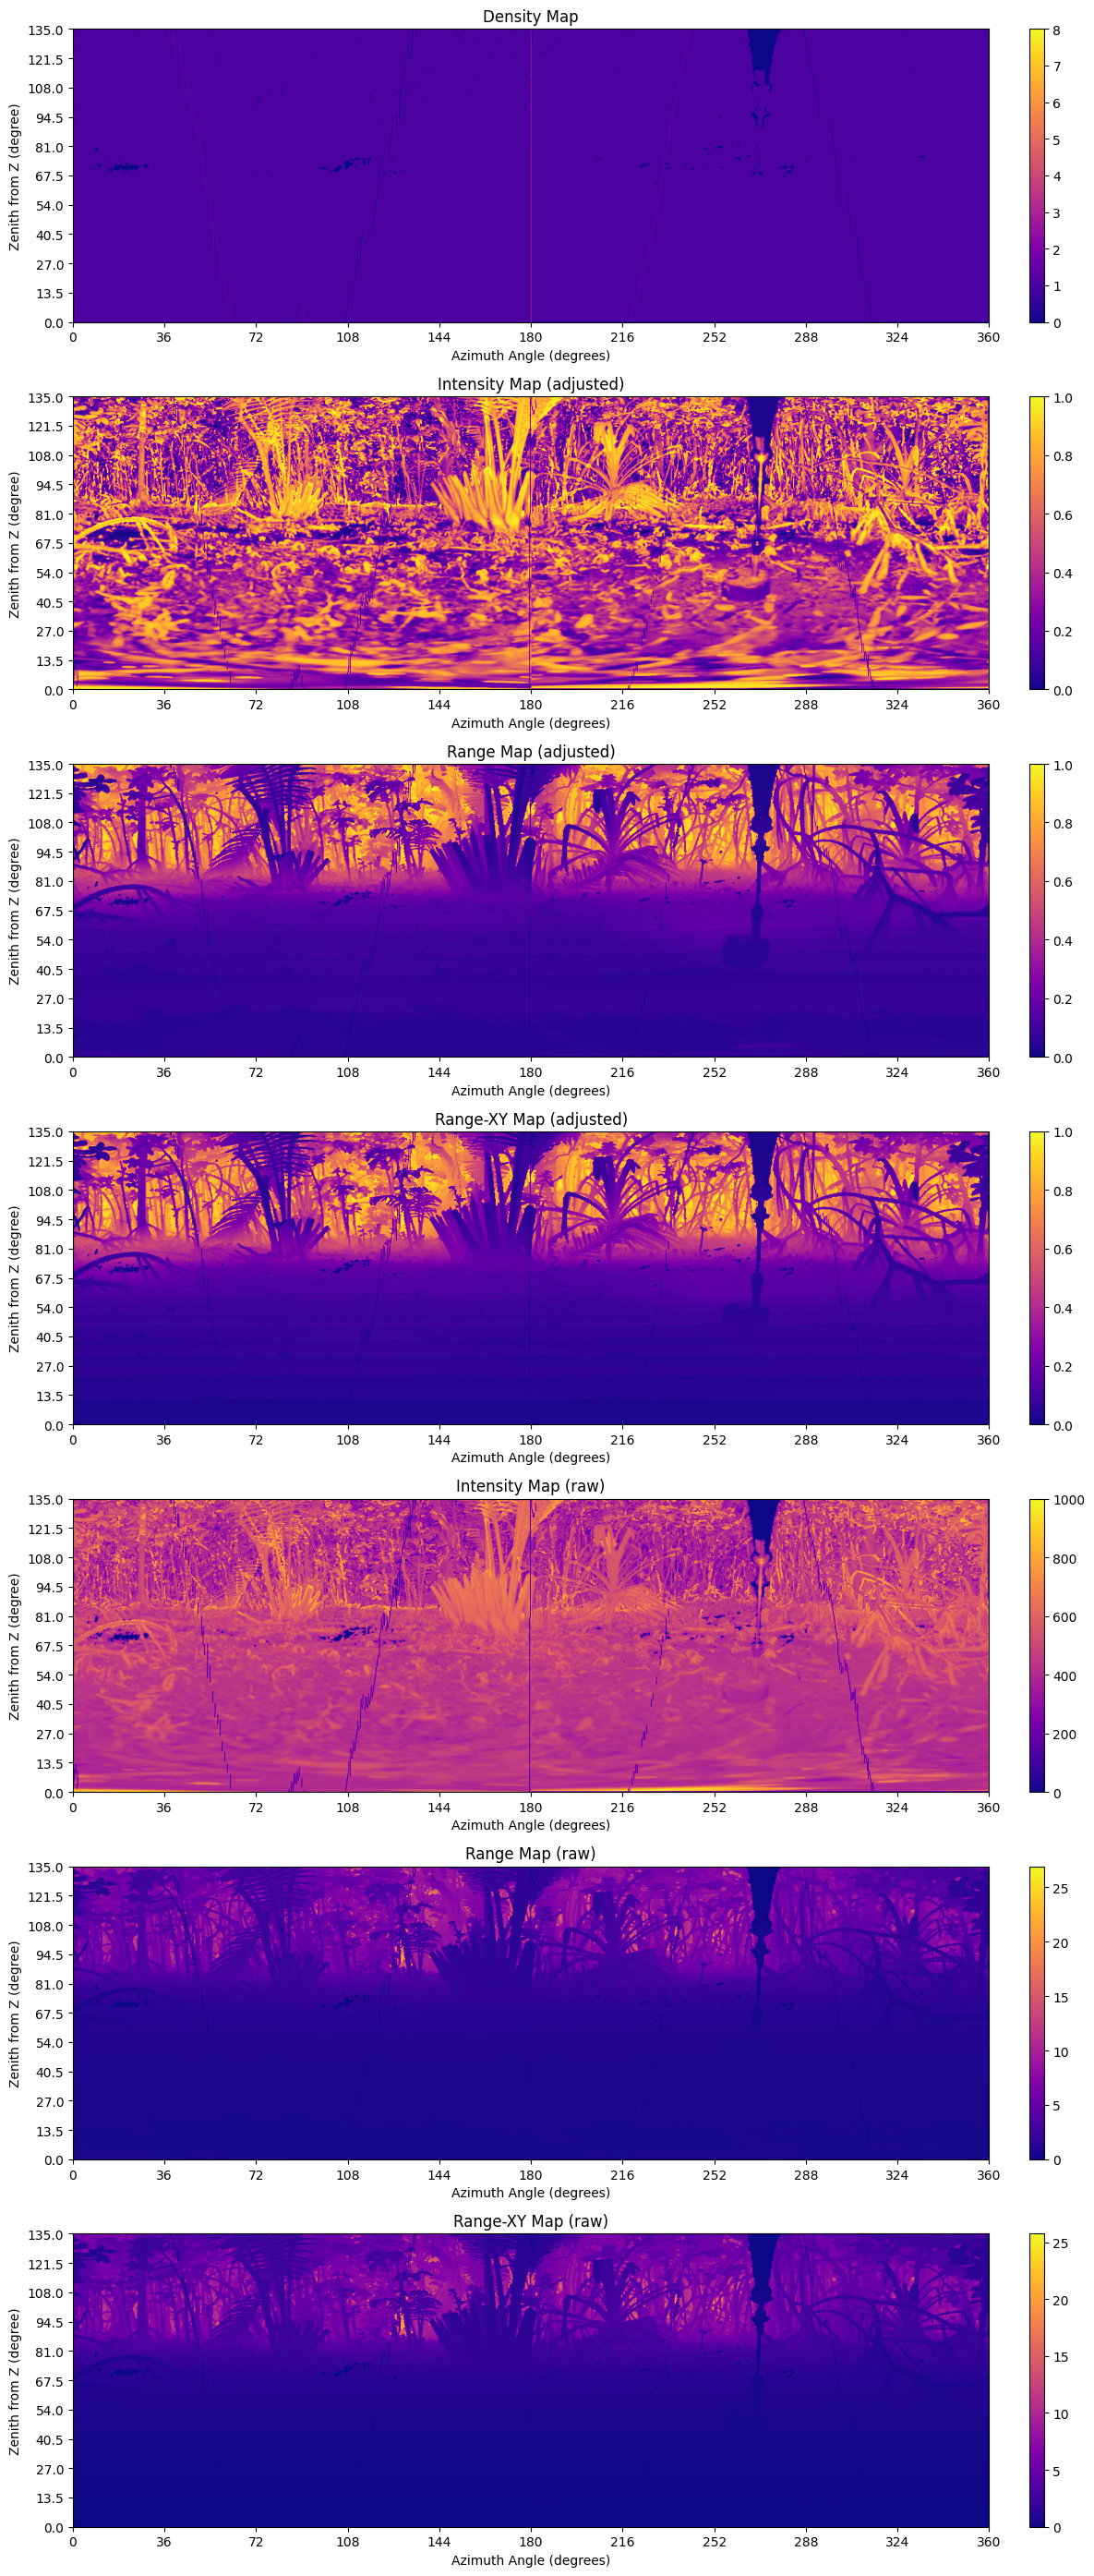

Images saved to ./outputs directory


In [62]:
df_filtered, output_images = unwrap_point_cloud_to_2d_images(filename, hdr_method='clahe')
density_image, intensity_image_adjusted, range_image_adjusted, range_xy_image_adjusted, intensity_image, range_image, range_xy_image = output_images
titles = ['Density Map', 'Intensity Map (adjusted)', 'Range Map (adjusted)', 'Range-XY Map (adjusted)', 'Intensity Map (raw)', 'Range Map (raw)', 'Range-XY Map (raw)']
display_density_images(density_image, saveflag=saveflag)
get_image_histogram(image_data=density_image, title='density', saveflag=saveflag)


# Step 7: Display and save the adjusted intensity and range images
display_unwrapped_images(output_images, 
                        titles=titles,
                        saveflag=saveflag)



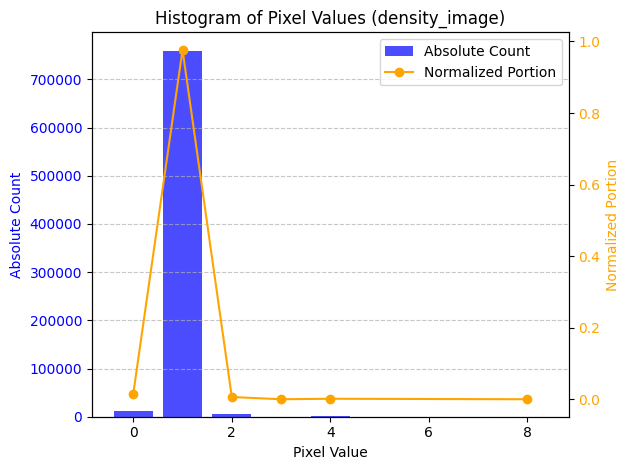

Histogram:
Values: [0. 1. 2. 3. 4. 8.]
Counts: [ 12184 759503   4827     19   1065      2]
Normalized Counts: [0.016 0.977 0.006 0.    0.001 0.   ]


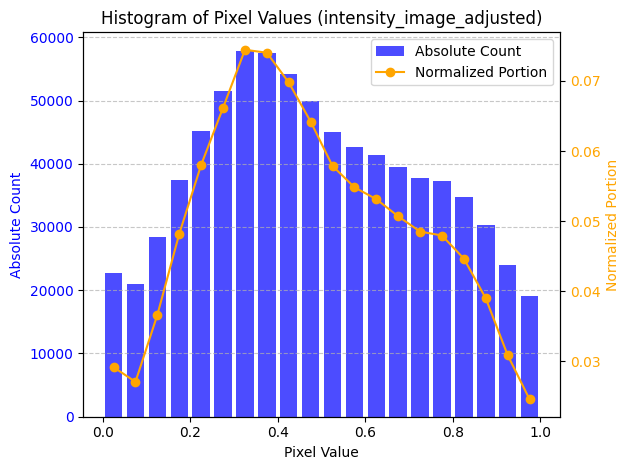

Histogram:
Values: [0.025      0.075      0.125      0.17500001 0.225      0.275
 0.325      0.375      0.425      0.475      0.525      0.57500005
 0.625      0.67499995 0.725      0.775      0.82500005 0.875
 0.92499995 0.975     ]
Counts: [22692 21062 28495 37481 45124 51456 57885 57565 54269 49931 45006 42639
 41322 39421 37730 37292 34732 30329 24033 19136]
Normalized Counts: [0.029 0.027 0.037 0.048 0.058 0.066 0.074 0.074 0.07  0.064 0.058 0.055
 0.053 0.051 0.049 0.048 0.045 0.039 0.031 0.025]


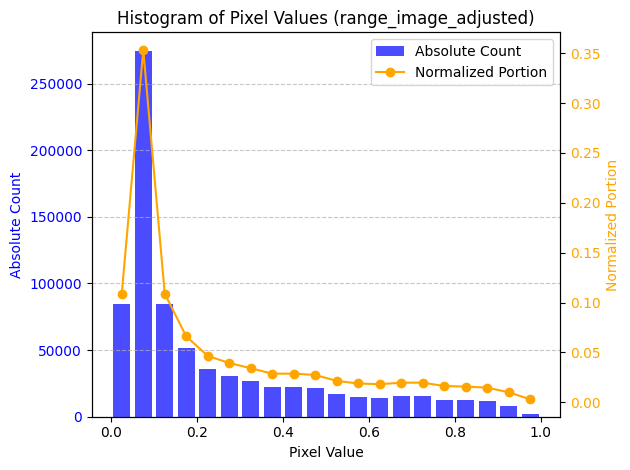

Histogram:
Values: [0.025      0.075      0.125      0.17500001 0.225      0.275
 0.325      0.375      0.425      0.475      0.525      0.57500005
 0.625      0.67499995 0.725      0.775      0.82500005 0.875
 0.92499995 0.975     ]
Counts: [ 84688 274739  84596  51369  36167  30680  26565  22331  22348  21326
  16697  14683  14121  15289  15325  12719  12261  11461   7836   2399]
Normalized Counts: [0.109 0.353 0.109 0.066 0.047 0.039 0.034 0.029 0.029 0.027 0.021 0.019
 0.018 0.02  0.02  0.016 0.016 0.015 0.01  0.003]


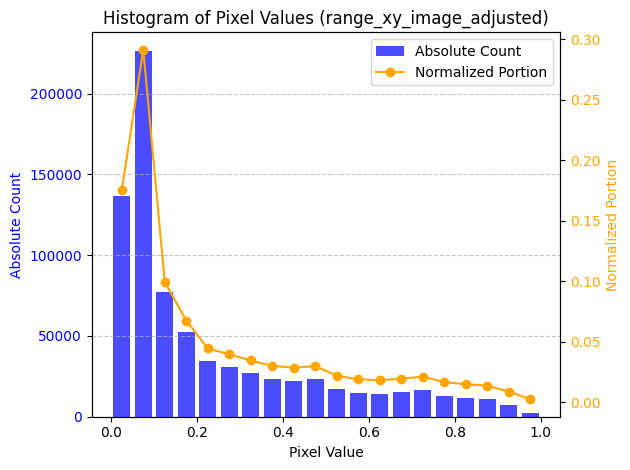

Histogram:
Values: [0.025      0.075      0.125      0.17500001 0.225      0.275
 0.325      0.375      0.425      0.475      0.525      0.57500005
 0.625      0.67499995 0.725      0.775      0.82500005 0.875
 0.92499995 0.975     ]
Counts: [136398 226554  77335  52617  34678  30973  26984  23490  22336  23315
  17248  14826  14317  15223  16605  13131  11673  10837   7010   2050]
Normalized Counts: [0.175 0.291 0.099 0.068 0.045 0.04  0.035 0.03  0.029 0.03  0.022 0.019
 0.018 0.02  0.021 0.017 0.015 0.014 0.009 0.003]


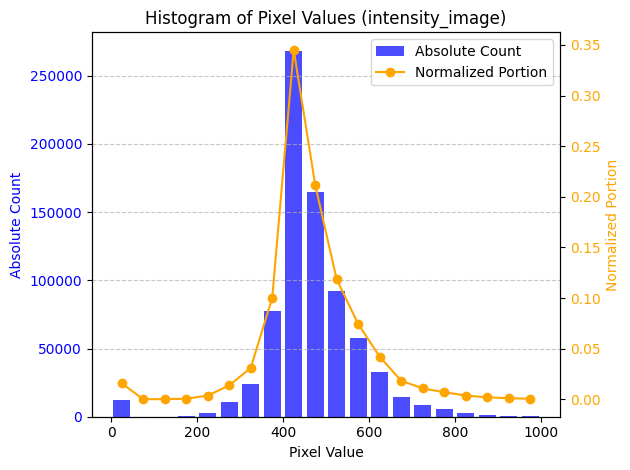

Histogram:
Values: [ 25.  75. 125. 175. 225. 275. 325. 375. 425. 475. 525. 575. 625. 675.
 725. 775. 825. 875. 925. 975.]
Counts: [ 12184     16    133    420   2866  10635  24080  77834 268419 164748
  92041  57850  32711  14265   8345   5465   2838   1538    800    412]
Normalized Counts: [0.016 0.    0.    0.001 0.004 0.014 0.031 0.1   0.345 0.212 0.118 0.074
 0.042 0.018 0.011 0.007 0.004 0.002 0.001 0.001]


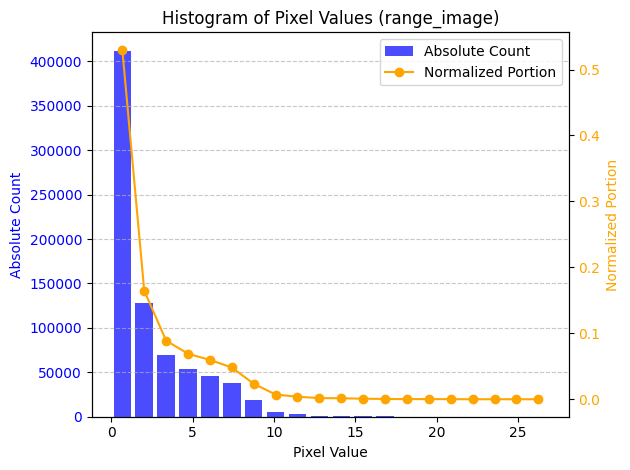

Histogram:
Values: [ 0.672975   2.018925   3.3648748  4.710825   6.056775   7.402725
  8.748674  10.094625  11.440575  12.786526  14.132475  15.478425
 16.824375  18.170326  19.516275  20.862225  22.208176  23.554127
 24.900076  26.246025 ]
Counts: [412093 128069  69139  53638  46384  37457  18294   5583   2998   1350
   1186    636    328    151    174     87     22      6      2      3]
Normalized Counts: [0.53  0.165 0.089 0.069 0.06  0.048 0.024 0.007 0.004 0.002 0.002 0.001
 0.    0.    0.    0.    0.    0.    0.    0.   ]


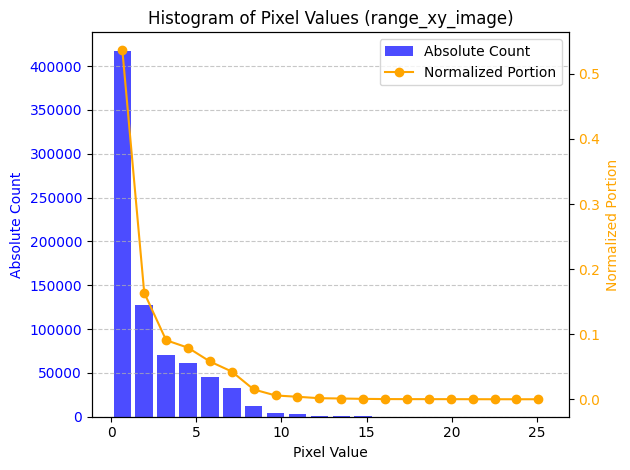

Histogram:
Values: [ 0.6435692  1.9307075  3.217846   4.5049844  5.792123   7.079261
  8.3664     9.653538  10.940676  12.227815  13.514953  14.802092
 16.08923   17.37637   18.663506  19.950645  21.237782  22.524921
 23.812061  25.099197 ]
Counts: [417568 127245  70554  61579  45147  33080  11693   4520   2971   1252
    884    472    217    141    113    102     51      8      0      3]
Normalized Counts: [0.537 0.164 0.091 0.079 0.058 0.043 0.015 0.006 0.004 0.002 0.001 0.001
 0.    0.    0.    0.    0.    0.    0.    0.   ]


In [63]:
titles = ['density_image', 'intensity_image_adjusted', 'range_image_adjusted', 'range_xy_image_adjusted', 'intensity_image', 'range_image', 'range_xy_image']
for hist_image, title in zip(output_images, titles):
    get_image_histogram(image_data=hist_image, title=title, saveflag=False)

## Attach segmentation bitmap colors to points

In [64]:
def attach_segmentation_colors_to_points(pts_df: pd.DataFrame, seg_map_path: str, output_filename: str) -> pd.DataFrame:
    """
    Attach the color of the pixels in the segmentation map back to the points in the point cloud DataFrame.

    Parameters:
    -----------
    pts_df : pd.DataFrame
        The filtered point cloud DataFrame with pixel coordinates.
    seg_map_path : str
        The path to the segmentation map image file.
    output_filename : str
        The path to save the colorized point cloud data.

    Returns:
    --------
    pd.DataFrame
        The DataFrame with additional columns for RGB values.
    """
    # Step 8: Attach the color of the pixels in the segmentation map back to the points
    ## read the segmented image
    seg_map = io.imread(seg_map_path)  # (height, width, rgb-channels)

    # Create new columns in the DataFrame for RGB values and initialize them
    pts_df.loc[:, 'red'] = np.nan
    pts_df.loc[:, 'green'] = np.nan
    pts_df.loc[:, 'blue'] = np.nan

    # Extract unique pixel coordinates and map their RGB values
    pxpy_indices = pts_df[['y_pix', 'x_pix']].drop_duplicates().values
    rgb_values = seg_map[pxpy_indices[:, 0], pxpy_indices[:, 1]]
    coord_to_rgb = dict(zip(map(tuple, pxpy_indices), rgb_values))

    # Apply RGB values to the DataFrame using a vectorized operation
    coords = pts_df[['y_pix', 'x_pix']].apply(tuple, axis=1)
    rgb_data = coords.map(coord_to_rgb)

    # Assign RGB values to the corresponding columns
    pts_df[['red', 'green', 'blue']] = pd.DataFrame(rgb_data.tolist(), index=pts_df.index)

    # Save the colorized point cloud to a text file
    pts_df.to_csv(output_filename, sep='\t', index=False)
    print(f'Colorized point cloud data saved to {output_filename}!')
    
    return pts_df

# # Example usage
if save_pts_with_colors:
    output_filename = f'{output_dir}/{os.path.basename(filename)[:-4]}_2d_segmap_labeld.txt'
    pts_df_colored = attach_segmentation_colors_to_points(df_filtered, seg_map_path, output_filename)

## Combine Unwrapped images to an psudo-RGB image

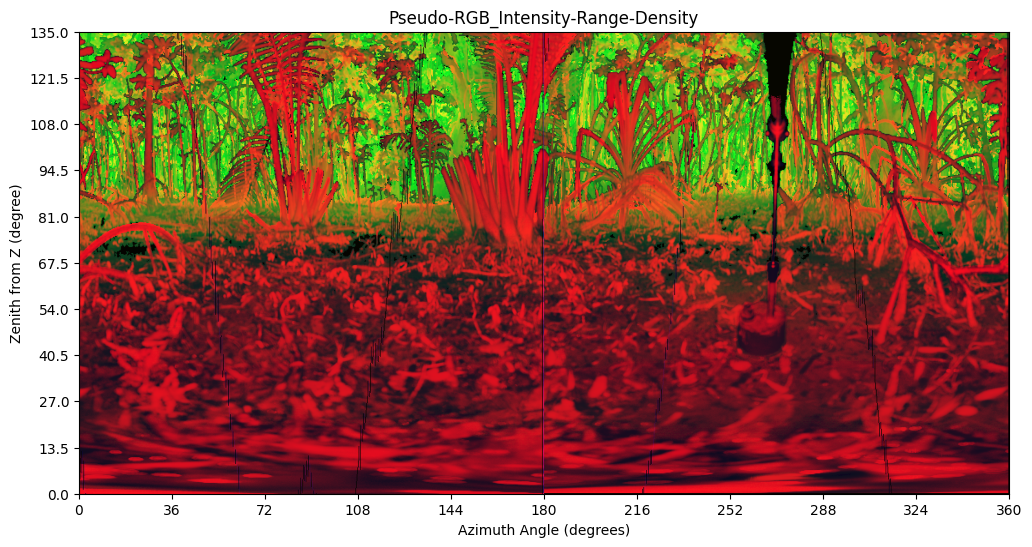

In [65]:
def create_pseudo_rgb_image(intensity_image: np.ndarray, range_image: np.ndarray, density_image: np.ndarray, saveflag:bool=False) -> np.ndarray:
    """
    Combine intensity, range, and density images into a pseudo-RGB image.

    Parameters:
    -----------
    intensity_image : np.ndarray
        The adjusted intensity image.
    range_image : np.ndarray
        The adjusted range image.
    density_image : np.ndarray
        The density image.

    Returns:
    --------
    np.ndarray
        The pseudo-RGB image.
    """
    # Normalize the images to the range [0, 1]
    intensity_norm = (intensity_image - intensity_image.min()) / (intensity_image.max() - intensity_image.min())
    range_norm = (range_image - range_image.min()) / (range_image.max() - range_image.min())
    density_norm = (density_image - density_image.min()) / (density_image.max() - density_image.min())

    # Stack the normalized images to create an RGB image
    # pseudo_rgb_image = np.stack((intensity_norm, range_norm, density_norm), axis=-1)
    pseudo_rgb_image = np.stack((intensity_norm, range_norm, density_norm), axis=-1)

    # Display the pseudo-RGB image
    # Define custom ticks using np.linspace
    y_ticks = np.linspace(0, ZENITH_NORM_SCALE, CANVAS_HEIGHT + 1)
    x_ticks = np.linspace(0, AZIMUTH_NORM_SCALE, CANVAS_WIDTH + 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(pseudo_rgb_image, aspect='auto', extent=[x_ticks[0], x_ticks[-1], y_ticks[0], y_ticks[-1]])
    figure_title = 'Pseudo-RGB_Intensity-Range-Density'
    plt.title(figure_title)
    plt.xticks(x_ticks[::int(len(x_ticks) / 10)])  # Reduce the number of x-ticks to avoid overlap
    plt.yticks(y_ticks[::int(len(y_ticks) / 10)])  # Reduce the number of y-ticks for readability
    plt.xlabel('Azimuth Angle (degrees)')
    plt.ylabel('Zenith from Z (degree)')
    plt.show()

    if saveflag:
        plt.imsave(f'{output_dir}/{figure_title}.png', pseudo_rgb_image)

    return pseudo_rgb_image

# Create the pseudo-RGB image
pseudo_rgb_image = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, density_image, saveflag=saveflag)

